In [2]:
import datetime, calendar, glob, os, requests, pickle

import pickle as pkl
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.colors as mcolors
import networkx as nx

from matplotlib import cm
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.transforms import ScaledTranslation
from skfda.exploratory.depth import ModifiedBandDepth, IntegratedDepth

from datetime import datetime

from shapely.geometry import box
from shapely.ops import unary_union
from fda_utils import _fDepth, _fQuantile

from fdu import functional_dynamic_update

plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.handleheight"] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_data = "/Users/Guille/Desktop/dynamic_update/data"
path_to_images = "/Users/Guille/Desktop/dynamic_update/images"
path_to_params = "/Users/Guille/Desktop/dynamic_update/params"
path_to_validation = "/Users/Guille/Desktop/dynamic_update/validation"
path_to_fDepth = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update/fDepth"

# Loading color palette
palette_ = pd.read_csv(path_to_data + "/palette.csv")
print(palette_)

# Loading Texas map
TX_ = gpd.read_file(path_to_data + "/maps/TX/State.shp")

T = 288
resource = 'wind'

      miro      ibm
0  #013396  #648FFF
1  #B1C06E  #785EF0
2  #056534  #DC267F
3  #F80202  #FE6100
4  #FDD906  #FFB000
5  #FCF795      NaN
6  #CCEDFF      NaN
7  #FDD60B      NaN
8  #FCE9D0      NaN


In [17]:
# load dataset
def _load_dataset(region, N_test_sampels, path, file_name):
    print(region, N_test_sampels)
    
    zone = region
    N = N_test_sampels
    # load
    with open(path + file_name, "rb") as f:
        _DATA = pickle.load(f)

    DT_tr_ = np.concatenate([_DATA[zone]['datetime_actuals'][:-N, ...] for i in range(_DATA[zone]['actuals'].shape[0])], axis = 0)
    DT_ts_ = _DATA[zone]['datetime_actuals'][-N:, ...]
    #print(DT_tr_.shape, DT_ts_.shape)
    
    d_tr_ = np.concatenate([_DATA[zone]['datetime_actuals'][:-N, 0, 24] for i in range(_DATA[zone]['actuals'].shape[0])], axis = 0)
    d_ts_ = _DATA[zone]['datetime_actuals'][-N:, 0, 24]
    d_tr_ = pd.to_datetime(d_tr_).dayofyear.to_numpy()
    d_ts_ = pd.to_datetime(d_ts_).dayofyear.to_numpy()

    datetime_tr_ = _DATA[zone]['datetime_actuals'][:-N, ...]
    datetime_ts_ = _DATA[zone]['datetime_actuals'][-N:, ...]

    F_tr_ = np.concatenate([_DATA[zone]['actuals'][i, :-N, ...] for i in range(_DATA[zone]['actuals'].shape[0])], axis = 0)
    F_ts_ = _DATA[zone]['actuals'][:, -N:, ...]
    print(F_tr_.min(), F_tr_.max())
    print(F_ts_.min(), F_ts_.max())
    #print(F_tr_.shape, F_ts_.shape)

    E_tr_ = np.concatenate([_DATA[zone]['forecasts'][i, :-N, ...] for i in range(_DATA[zone]['actuals'].shape[0])], axis = 0)
    E_ts_ = _DATA[zone]['forecasts'][:, -N:, ...]
    print(E_tr_.min(), E_tr_.max())
    print(E_ts_.min(), E_ts_.max())
    #print(E_tr_.shape, E_ts_.shape)

    dt_ = np.linspace(0, DT_ts_.shape[-1] - 1, DT_ts_.shape[-1])*12*5
    #print(dt_.shape, d_ts_.shape)

    return F_tr_, F_ts_, E_tr_, E_ts_, d_tr_, d_ts_, datetime_tr_, datetime_ts_, dt_


interval = 6
zone = 0
day = 1
print(zone, interval, day)

regions_ = ['Coastal', 
            'North',
            'Panhandle',
            'South',
            'West']

F_tr_, F_ts_, E_tr_, E_ts_, d_tr_, d_ts_, t_tr_, t_ts_, dt_ = _load_dataset(region = regions_[zone],
                                                                            N_test_sampels = 50, 
                                                                            path = path_to_data, 
                                                                            file_name = "/gridstatus/processed_ERCOT_wind_data.pkl")
print(F_tr_.shape, F_ts_.shape, E_tr_.shape, E_ts_.shape, d_tr_.shape, d_ts_.shape,  t_tr_.shape, t_ts_.shape, dt_.shape)

dx_ = np.array([t_ts.strftime('%m-%d %H:%M') for t_ts in t_ts_[day, interval]])
print(dx_.shape)

import importlib
import fdu

importlib.reload(fdu)

_distances = {'temporal': 'seasonal', 'spatial': 'None'}

_fdu = fdu.functional_dynamic_update(_distances, regions_[0], dx_[24])
print(_fdu.name, _fdu.date)

# day = d_ts_[d]

0 6 1
Coastal 50
0.0 0.8736481340441737
0.0 0.8306343147946202
0.0 0.9613606951377334
0.0 0.868502362777172
(1065, 24, 72) (3, 50, 24, 72) (1065, 24, 48) (3, 50, 24, 48) (1065,) (50,) (355, 24, 72) (50, 24, 72) (72,)
(72,)
Coastal 11-08 06:00


In [18]:
F_tr_p_ = F_tr_[:, interval, :]
E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
print(F_tr_p_.shape, E_tr_p_.shape, dt_.shape, d_tr_.shape, d_ts_.shape)

_fdu.fit(F_tr_p_, E_tr_p_, dt_, 
         t_ = d_tr_, 
         t = day)

f_ = F_ts_[zone, day, interval, :24]
f_hat_ = F_ts_[zone, day, interval, 24:]
e_ = E_ts_[zone, day, interval, :]
e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
print(f_.shape, f_hat_.shape, e_p_.shape)

M_ = _fdu.predict(f_, e_p_,
                  forget_rate_f = .1,
                  forget_rate_e = 0.01,
                  length_scale_f = .1,
                  length_scale_e = 1.,
                  lookup_rate = 4,
                  trust_rate = 0.75,
                  nu = 12,
                  gamma = 60,
                  xi = 0.9,
                  kappa = 100,
                  p_fusion = 1.)

print(M_.shape)
print(_fdu.w_.shape, _fdu.idx_neighbors_.shape, _fdu.idx_temporal_.shape, _fdu.idx_spatial_.shape)
print(_fdu.psi_.shape, _fdu.phi_.shape)


(1065, 72) (1065, 72) (72,) (1065,) (50,)
(24,) (48,) (72,)
debugging
24 48
(24,) (48,)
(24,)
(24,) (48,) (72,)
(100, 48)
(1065,) (179,) (14,) (100,)
(72,) (24,)


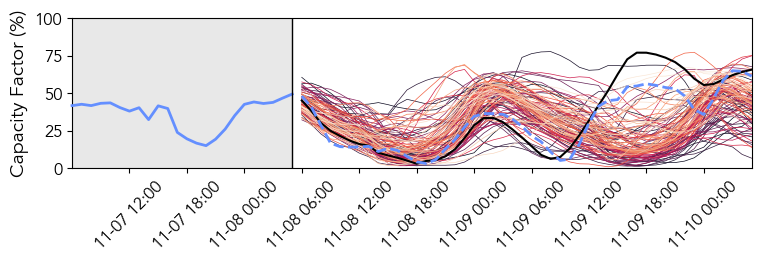

In [19]:
def _plot_forecasts(_ax, 
                    E_tr_, 
                    w_, 
                    idx_, 
                    f_, 
                    f_hat_, 
                    e_, 
                    dx_, 
                    dt_, 
                    interval, 
                    legend = False):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0, 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$E_{\star} \left([\tau, s]\right)$", 
             c="k")
    
    _ax.plot(tau_, 100. * f_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             zorder=10,
             #label="CF (ac)",
             lw=2)

    _ax.plot(s_, 100. * f_hat_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             zorder=10,
             lw=2,
             ls="--")

    _ax.plot(dt_, 100. * e_, 
             clip_on=False, 
             lw=1.5, 
             zorder=9, 
             #label="CF (fc)", 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * E_tr_[i, :], 
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)
    
    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=1.0, 
                zorder=11)

    n = int(dt_.shape[0]/12)
    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation=45)

    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

e_p_[:24] = np.nan
E_tr_p_[:, :24] = np.nan

_plot_forecasts(_ax, 
                E_tr_p_, 
                _fdu.w_, 
                _fdu.idx_spatial_, 
                f_, 
                f_hat_, 
                e_p_, 
                dx_, 
                dt_, 
                24)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

# plt.savefig(path_to_images + f"/dayahead_neighbors-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

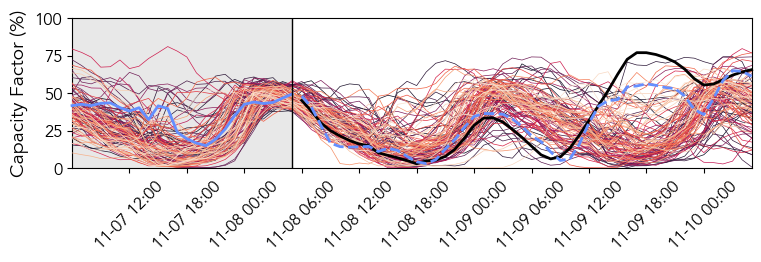

In [20]:
def _plot_neighbors(_ax, 
                    F_tr_, 
                    w_, 
                    idx_, 
                    f_, 
                    f_hat_, 
                    e_, 
                    dx_, 
                    dt_, 
                    interval):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1.)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\mathcal{F}_{\star} \left([\tau, s] \right)$", 
             c="k")
    
    _ax.plot(tau_, 100 * f_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             #label="CF (ac)", 
             lw=2, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             lw=2, 
             ls="--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             c="k", 
             clip_on = False)

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * F_tr_[i, :], 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 #c=_cmap(_norm(z_[i])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=1.0, 
                zorder=11)
    
    n = int(dt_.shape[0]/12)
    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation=45)
    _ax.set_ylim(0., 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

e_p_[:24] = np.nan
_plot_neighbors(_ax, 
                F_tr_p_, 
                _fdu.w_, 
                _fdu.idx_spatial_, 
                f_, 
                f_hat_, 
                e_p_, 
                dx_, 
                dt_, 
                24)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

# plt.savefig(path_to_images + f"/partial_neighbors-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

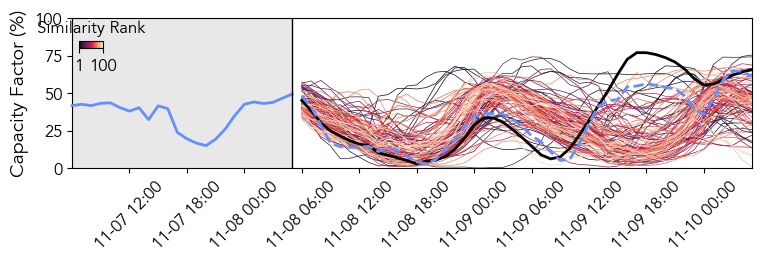

In [21]:
def _plot_updates(_fig, 
                  _ax, 
                  M_, 
                  f_, 
                  f_hat_, 
                  e_, 
                  w_, 
                  idx_, 
                  dx_, 
                  dt_, 
                  interval):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    
    w_selected_ = w_[idx_]
    
    idx_w_ = np.argsort(w_selected_)
    idx_   = idx_[idx_w_]
    
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\hat{\mu}_i(s)$", 
             c="k")

    _ax.plot(tau_, 100.0 * f_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             #label="CF (ac)",
             clip_on=False,
             lw=2)

    _ax.plot(s_, 100.0 * f_hat_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             lw=2,
             clip_on=False,
             ls="--")

    _ax.plot(dt_, 100.0 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             clip_on=False, 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_[interval:], 100 * M_[j, :],
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=0.5, 
                 zorder=8)
        
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=1.0, 
                #label="Event (update)", 
                zorder=11)

    n = int(dt_.shape[0]/12)

    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation=45)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)

    cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
                         cax=_ax.inset_axes([45, 80, 150, 5], transform=_ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, M_.shape[0]], 
                   size=12)
    
    #cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Similarity Rank", 
                      rotation=0, 
                      size=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_updates(_fig, 
              _ax, 
              M_, 
              f_, 
              f_hat_, 
              e_p_, 
              _fdu.w_, 
              _fdu.idx_spatial_, 
              dx_, 
              dt_, 
              24)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

# plt.savefig(path_to_images + f"/dynamic_update_neighbors-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

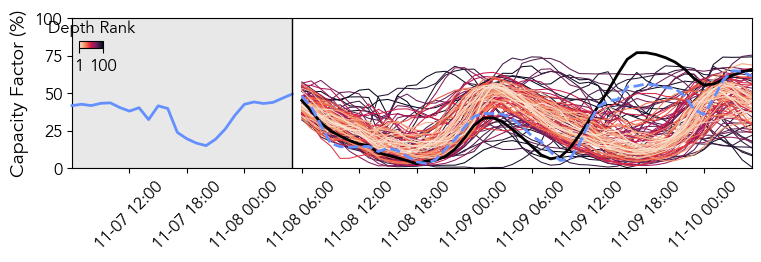

In [22]:
def _plot_depth(_fig, _ax, palette_, M_, f_, f_hat_, e_, w_, dx_, dt_, interval,
                colorbar = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    idx_  = np.argsort(w_)
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label = r"$\hat{\mu}_i(s)$", 
             c = "k")

    for i in range(idx_.shape[0]):
        _ax.plot(s_, 100 * M_[idx_[i], :],
                 c = _cmap(_norm(i/idx_.shape[0])), 
                 lw = 0.75, 
                 zorder = 0, 
                 clip_on = False)

    _ax.plot(dt_[:f_.shape[0]], 100 * f_,
             c = palette_.loc[0, "ibm"],
             #label = "CF (ac)",
             zorder = 9,
             lw = 2, 
             clip_on = False)

    _ax.plot(dt_[-f_hat_.shape[0]:], 100 * f_hat_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             ls = "--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             lw = 2, 
             #label = "CF (fc)", 
             zorder = 8,
             c = "k", 
             clip_on = False)

    _ax.axvline(dt_[f_.shape[0] - 1], 
                color = "k", 
                lw = 1, 
                #label  = "Event (update)", 
                zorder = 10)
        
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5,
                     zorder = 1)

    n = int(dt_.shape[0]/12)

    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation = 45)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(_norm, sns.color_palette("rocket_r", as_cmap = True)),
                             cax = _ax.inset_axes([45, 80, 150, 5], transform = _ax.transData),
                             orientation = "horizontal")
    
        cbar.set_ticks([0, 1], 
                       labels = [1, M_.shape[0]], 
                       size = 12)
            
        cbar.ax.set_title("Depth Rank", 
                          rotation = 0, 
                          size = 12)


_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

depth = 'MBD'
depth_rank_ = _fDepth(_fdu.M_, depth, path_to_fDepth).to_numpy()[:, 0]

_plot_depth(_fig, 
            _ax, 
            palette_, 
            _fdu.M_, 
            f_, 
            f_hat_, 
            e_p_, 
            depth_rank_, 
            dx_, 
            dt_, 24,
            colorbar = True)

# _ax.legend(frameon = False, 
#            loc = (0.4, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 5)

# plt.savefig(path_to_images + f"/ranking-{depth}_{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()

(49,)


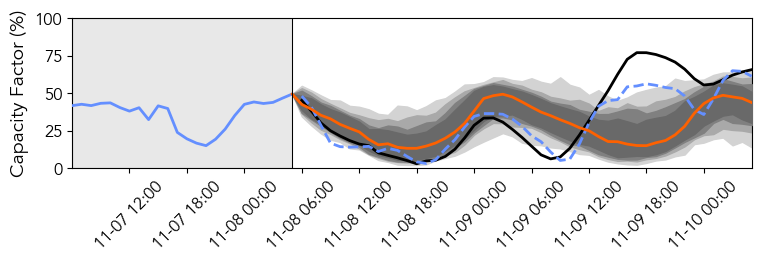

In [23]:
def _plot_envelop(_ax, _upper, _lower, m_, f_, f_hat_, e_, dt_, dx_, interval, 
                  color = palette_.loc[4, "ibm"],
                  label = r"$\bar{\mu} (s)$",
                  CR = 'CR',
                  legend_1 = True, 
                  legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_, 100*e_, 
             c = "k", 
             lw = 2, 
             clip_on = True,
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8)

    _ax.plot(tau_, 100*f_, 
             c = palette_.loc[0, "ibm"], 
             clip_on = True,
             label = "CF (actual)" if legend_1 else None, 
             lw = 2, 
             zorder = 9)
    
    _ax.plot(s_, 100*f_hat_, 
             clip_on = True,
             c = palette_.loc[0, "ibm"], 
             ls = "--", 
             lw = 2, 
             zorder = 9)

    _ax.plot(dt_[-m_.shape[0]:], 100*m_, 
             c = color, 
             label = label if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    colors_ = ["lightgray", "darkgray", "gray", "dimgray"]
    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]

        cr = int((1. - float(key))*100)

        _ax.fill_between(dt_[-u_.shape[0]:], 100*u_, 100*l_,
                         color  = color,
                         label  = f"{cr}% {CR}" if legend_2 else None,
                         zorder = i + 1)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)

    _ax.axvline(dt_[interval - 1], 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 11)

    n = int(dt_.shape[0]/12)
    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation=45)
        
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

# Calculate confidence intervals from Directional Quantiles
f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(_fdu.M_ext_, alpha_ = [0.1, 0.2, 0.3, 0.4])
print(f_median_ext_.shape)
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_median_ext_, f_, f_hat_, e_p_, dt_, dx_, 24, 
              color = palette_.loc[3, "ibm"],
              CR = 'CI',
              label = r"$\bar{\mu} (s)$",
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

plt.show()

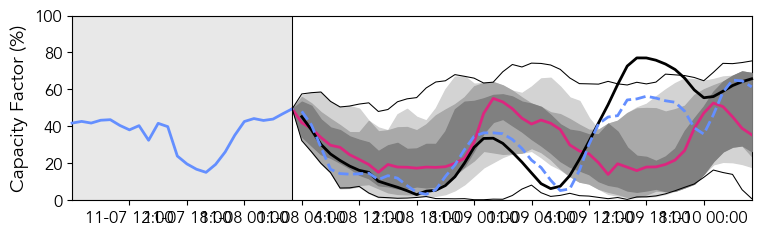

In [24]:
def _plot_enhanced_functional_boxplot(_ax, _upper, _lower, m_, f_, f_hat_, e_, dt_, dx_, interval,
                                      legend_1 = True, 
                                      legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_, 100 * e_, 
             c = "k", 
             lw = 2, 
             zorder = 8,
             #label = "CF (forecast)" if legend_1 else None
             clip_on = False)

    _ax.plot(tau_, 100 * f_, 
             c = palette_.loc[0, "ibm"], 
             #label = "CF (actual)" if legend_1 else None, 
             zorder = 9,
             lw = 2, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c  = palette_.loc[0, "ibm"], 
             lw = 2, 
             ls = "--", 
             zorder = 9,
             clip_on = False)
    #m_p_ = np.concatenate([f_[-1] * np.ones((1,)), m_], axis=0)

    _ax.plot(dt_[-m_.shape[0]:], 100 * m_, 
             c = palette_.loc[2, "ibm"], 
             ls = '-',
             zorder = 4,
             label = r"$\bar{\mu} (s)$" if legend_1 else None,
             lw = 2)
    
    u_ = _upper['max']
    l_ = _lower['min']

    _ax.plot(dt_[-u_.shape[0]:], 100 * u_, 
             c = 'k', 
             lw = .75, 
             zorder = 7)
    
    _ax.plot(dt_[-l_.shape[0]:], 100 * l_, 
             c = 'k', 
             lw = .75, 
             zorder = 7, 
             label = "min-max" if legend_2 else None)

    _upper.pop('max')
    _lower.pop('min')

    colors_ = ["lightgray", "darkgray", "gray"]

    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]

        cr = int((1. - float(key)) * 100)
        
        _ax.fill_between(dt_[-u_.shape[0]:], 100 * u_, 100 * l_,
                         color = color,
                         label = f"{cr}% CR" if legend_2 else None,
                         zorder = i + 1)

    _ax.axvline(dt_[interval - 1], 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 10)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)

    n = int(dt_.shape[0]/12)
    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation=0)
    # ax_[2].set_yticks(size = 12)
    _ax.set_ylim(0., 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)


# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(_fdu.M_ext_, depth_rank_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_enhanced_functional_boxplot(_ax, _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dt_, dx_, 24,
                                  legend_1 = False, 
                                  legend_2 = False)
    
# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 6)

# plt.savefig(path_to_images + f"/fboxplot-{depth}_{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()

(49,)


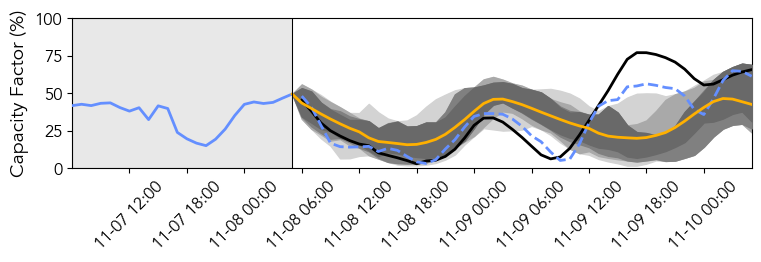

In [25]:
# Samples in each confidence band
dist = 'fknn'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = IntegratedDepth()
_depth = ModifiedBandDepth()

J_ = _fdu.focal_curve_envelope(_depth, _fdu.M_ext_, dist, max_iter = 100)

k_ = [1., 0.8, 0.6, 0.4]

f_focal_ext_, _upper, _lower = _fdu.focal_envelop_confidence_bands(alpha_, k_)
print(f_focal_ext_.shape)
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_focal_ext_, f_, f_hat_, e_p_, dt_, dx_, 24, 
              color = palette_.loc[4, "ibm"],
              label = r"$\bar{f} (s)$",
              CR = 'CR',
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

# plt.savefig(path_to_images + f"/focal_curve_envelop-{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()

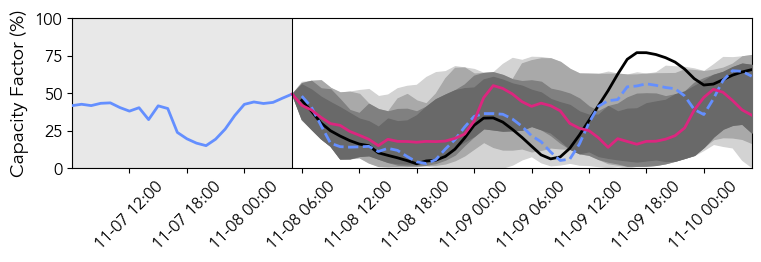

In [26]:
# Samples in each confidence band
depth = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]

k_ = [1, 0.8, 0.6, 0.4]

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(_depth, _fdu.M_ext_, alpha_, k_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dt_, dx_, 24, 
              CR = 'CR',
              label = r"$\tilde{f} (s)$",
              color = palette_.loc[2, "ibm"],
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

# plt.savefig(path_to_images + f"/depth-{depth}_{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

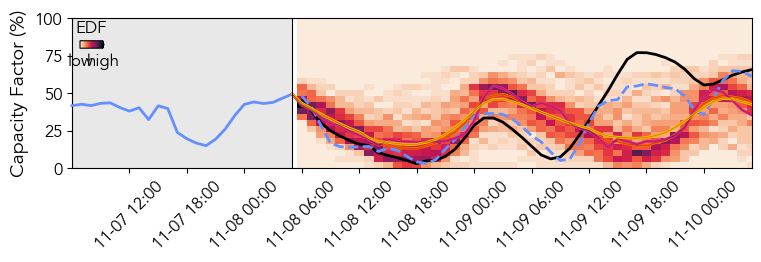

In [40]:
def _plot_density_heatmap(_fig, _ax, M_, f_median_, f_deepest_, f_focal_, f_, f_hat_, e_, dx_, dt_, interval, 
                          colorbar = True,
                          legend_1 = True,
                          legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    Z_ = []
    for i in range(M_.shape[1]):
        a_, b_ = np.histogram(100 * M_[:, i], 
                              bins = 25, 
                              range = (0, 100), 
                              density = True)
        Z_.append(a_)

    Z_     = np.stack(Z_).T
    X_, Y_ = np.meshgrid(dt_[interval:], (b_[1:] + b_[:-1]) / 2.0)

    _cmap = sns.color_palette("rocket_r", as_cmap = True)
    _ax.pcolormesh(X_, Y_, Z_, cmap = _cmap, alpha = 1.)

    _ax.plot(dt_[-f_median_.shape[0]:], 100 * f_median_, 
             c = palette_.loc[3, "ibm"], 
             label = r"$\bar{\mu} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(dt_[-f_median_.shape[0]:], 100 * f_median_, 
             c = 'k', 
             lw = .25,
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(dt_[-f_deepest_.shape[0]:], 100 * f_deepest_, 
             c = palette_.loc[2, "ibm"], 
             label = r"$\bar{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    _ax.plot(dt_[-f_deepest_.shape[0]:], 100 * f_deepest_, 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(dt_[-f_focal_.shape[0]:], 100 * f_focal_, 
             c = palette_.loc[4, "ibm"], 
             label = r"$\tilde{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(dt_[-f_focal_.shape[0]:], 100 * f_focal_, 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(tau_, 100 * f_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             label = "CF (actual)" if legend_1 else None, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c = palette_.loc[0, "ibm"], 
             zorder = 9,
             lw = 2, 
             ls = "--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             c = "k", 
             lw = 2, 
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8,
             clip_on = False)

    _ax.axvline(dt_[interval - 1], 
                color = "k", 
                linewidth = 0.75, 
                label = "Event (update)" if legend_1 else None,
                zorder = 10)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)

    n = int(dt_.shape[0]/12)
    _ax.set_xticks(dt_[n::n], dx_[n::n], rotation = 45)
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

    _ax.tick_params(axis = "both", labelsize = 12)

    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])

    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(cmap=_cmap),
                             cax = _ax.inset_axes([50, 80, 150, 5], transform=_ax.transData),
                             orientation = "horizontal",
                             extend = "max")
    
        cbar.set_ticks([0, 1], 
                       labels = ["low", "high"], 
                       fontsize = 12)
        
        cbar.ax.tick_params(length=0)
    
        cbar.ax.set_title("EDF", rotation=0)
    
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), 
                         constrained_layout = True)

_plot_density_heatmap(_fig, _ax, _fdu.M_, _fdu.f_median_ext_, _fdu.f_deepest_ext_, _fdu.f_focal_ext_,
                      f_, f_hat_, e_p_, dx_, dt_, 24, 
                      colorbar = True,
                      legend_1 = False,
                      legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.0125, .8),
#            fontsize = 12, 
#            ncol = 3)

# plt.savefig(path_to_images + f"/heatmap-{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()